In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
import math
from sklearn.model_selection import train_test_split

In [48]:
loan_data = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')
loan_data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [49]:
print(loan_data.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [50]:
loan_data.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [51]:
loan_data['Gender'].fillna(loan_data['Gender'].mode()[0], inplace=True)
loan_data['Self_Employed'].fillna(loan_data['Self_Employed'].mode()[0], inplace=True)
loan_data['Dependents'].fillna(loan_data['Dependents'].mode()[0], inplace=True)
loan_data['LoanAmount'].fillna(loan_data['LoanAmount'].mode()[0], inplace=True)
loan_data['Loan_Amount_Term'].fillna(loan_data['Loan_Amount_Term'].mode()[0], inplace=True)
loan_data['Credit_History'].fillna(loan_data['Credit_History'].mode()[0], inplace=True )

/tmp/ipykernel_1114/1350243216.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_data['Gender'].fillna(loan_data['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_1114/1350243216.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(valu

In [52]:
loan_data.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,3
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [53]:
loan_data['Gender'] = loan_data['Gender'].map({'Male': 0, 'Female': 1})
loan_data['Married'] = loan_data['Married'].map({'Yes': 0, 'No': 1})
loan_data['Education'] = loan_data['Education'].map({'Graduate': 0, 'Not Graduate': 1})
loan_data['Self_Employed'] = loan_data['Self_Employed'].map({'Yes': 0, 'No': 1})
loan_data['Property_Area'] = loan_data['Property_Area'].map({'Urban': 0, 'Semiurban': 1, 'Rural': 2})
loan_data['Dependents'] = loan_data['Dependents'].replace('3+', 3)
loan_data['Dependents'] = pd.to_numeric(loan_data['Dependents'])

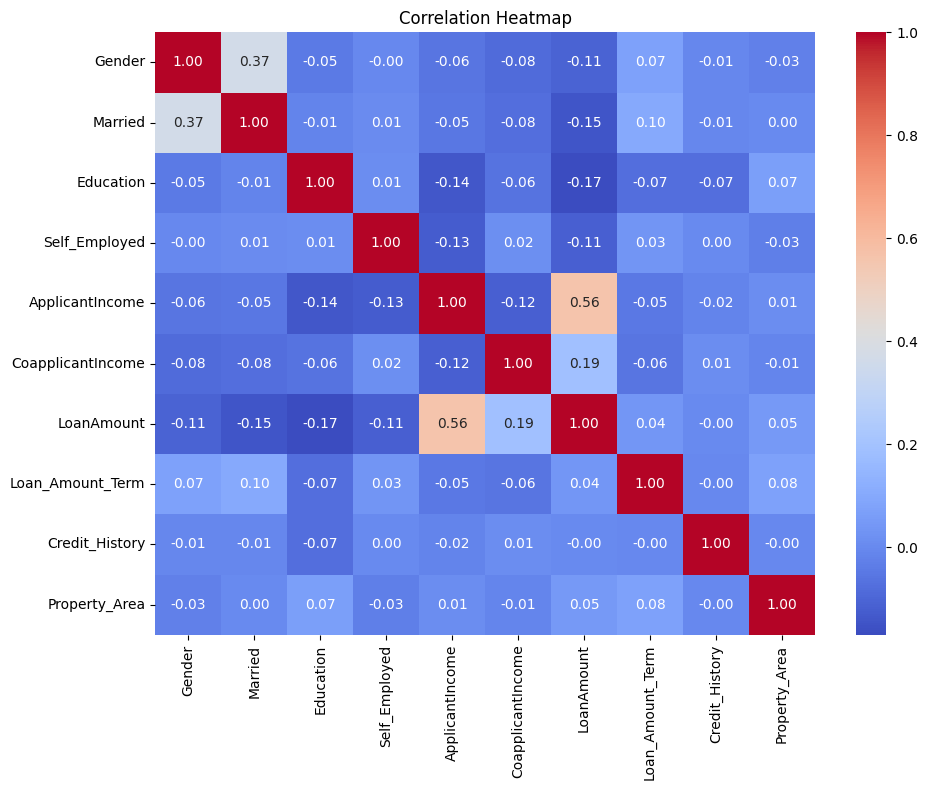

In [54]:
columns_for_heatmap = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History',
    'Property_Area'
]

corr = loan_data[columns_for_heatmap].corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

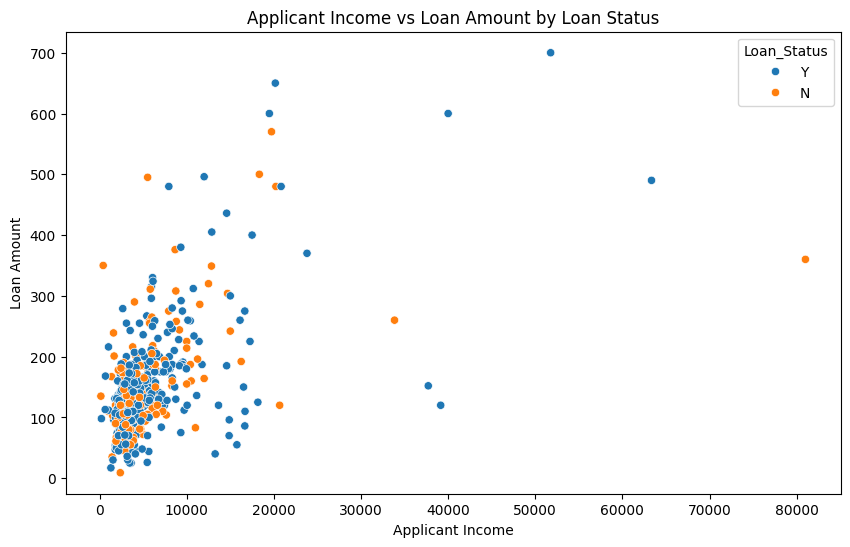

In [55]:
##1- Applicant Income and Loan Amount with Loan_Status
plt.figure(figsize=(10, 6))
sns.scatterplot(data=loan_data, x='ApplicantIncome', y='LoanAmount', hue='Loan_Status')
plt.title('Applicant Income vs Loan Amount by Loan Status')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.show()

Scatter Plot Documentation: Relationship Between Applicant Income and Loan Amount¶
Weak positive correlation between income and loan amount: Higher-income applicants tend to apply for larger loans.
Significant variation in loan amounts: Loan amounts vary widely, regardless of income level.
Both loan statuses (approved/rejected) appear across all income and loan amount ranges.
Income alone may not be a strong predictor of loan approval.

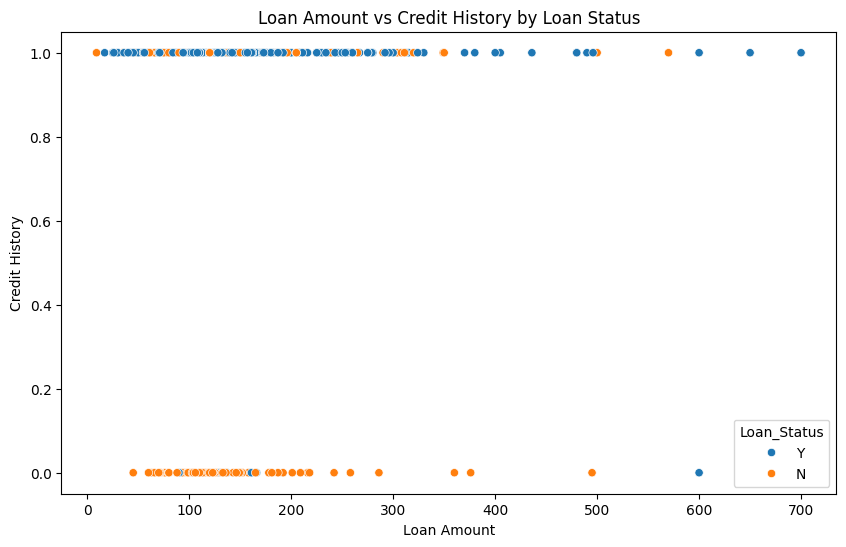

In [56]:
##2- Loan Amount and Credit History with Loan_Status
plt.figure(figsize=(10, 6))
sns.scatterplot(data=loan_data, x='LoanAmount', y='Credit_History', hue='Loan_Status')
plt.title('Loan Amount vs Credit History by Loan Status')
plt.xlabel('Loan Amount')
plt.ylabel('Credit History')
plt.show()

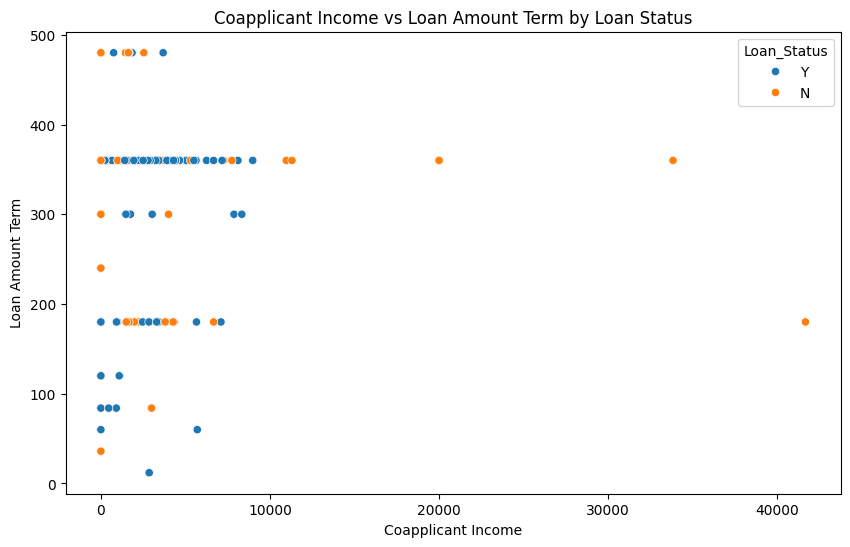

In [57]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=loan_data, x='CoapplicantIncome', y='Loan_Amount_Term', hue='Loan_Status')
plt.title('Coapplicant Income vs Loan Amount Term by Loan Status')
plt.xlabel('Coapplicant Income')
plt.ylabel('Loan Amount Term')
plt.show()

Scatter Plot Documentation: Relationship Between Coapplicant Income and

Loan Amount Term¶
No strong correlation between coapplicant income and loan amount term or loan approval status.
The points are randomly scattered across the plot, showing no clear patterns.
The points are color-coded based on loan status:
Blue: Loan approved.
Orange: Loan denied.
The plot suggests that coapplicant income does not significantly influence the loan amount term or whether the loan is approved.

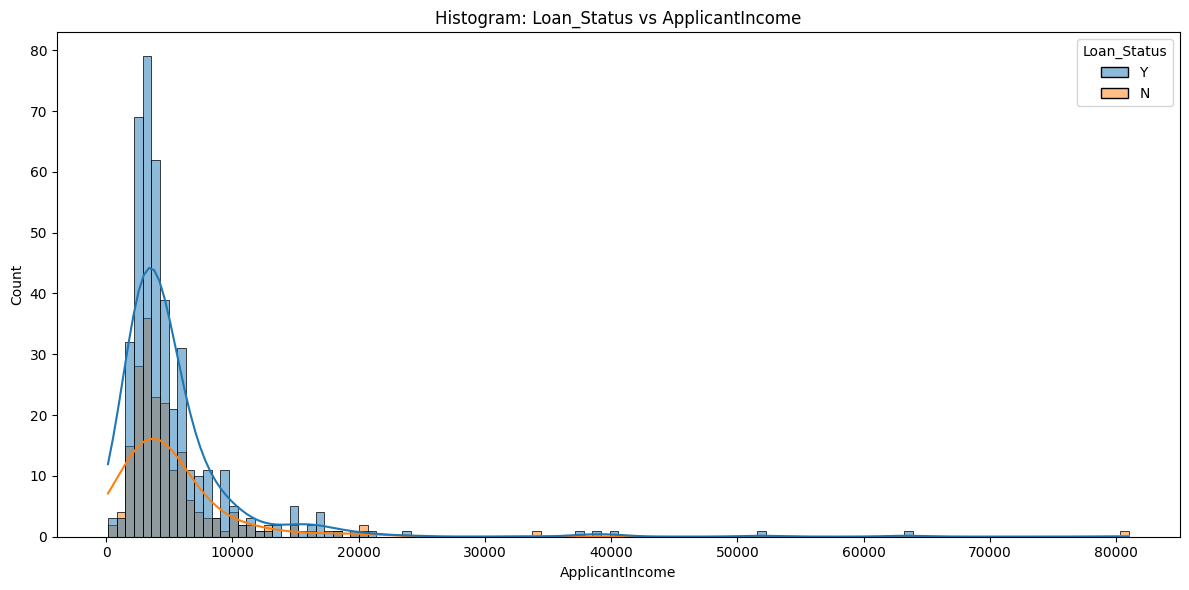

In [58]:
#Plots histograms for numerical data to visualize their distributions and understand the underlying frequency of the data
plt.figure(figsize=(12, 6))
sns.histplot(data=loan_data, x='ApplicantIncome', hue='Loan_Status', kde=True)
plt.title('Histogram: Loan_Status vs ApplicantIncome')
plt.tight_layout()
plt.show()

Histogram Documentation: Distribution of Applicant Income by Loan Status
This histogram shows the distribution of applicant income for individuals who were approved for a loan (Loan_Status=Y) and those who were not approved (Loan_Status=N).
The ApplicantIncome distribution is right-skewed, indicating that most applicants have lower incomes.
A higher number of applicants with lower income were approved for loans, suggesting that income may have an impact on loan approval status.
The graph reveals a relationship between applicant income and loan approval status.


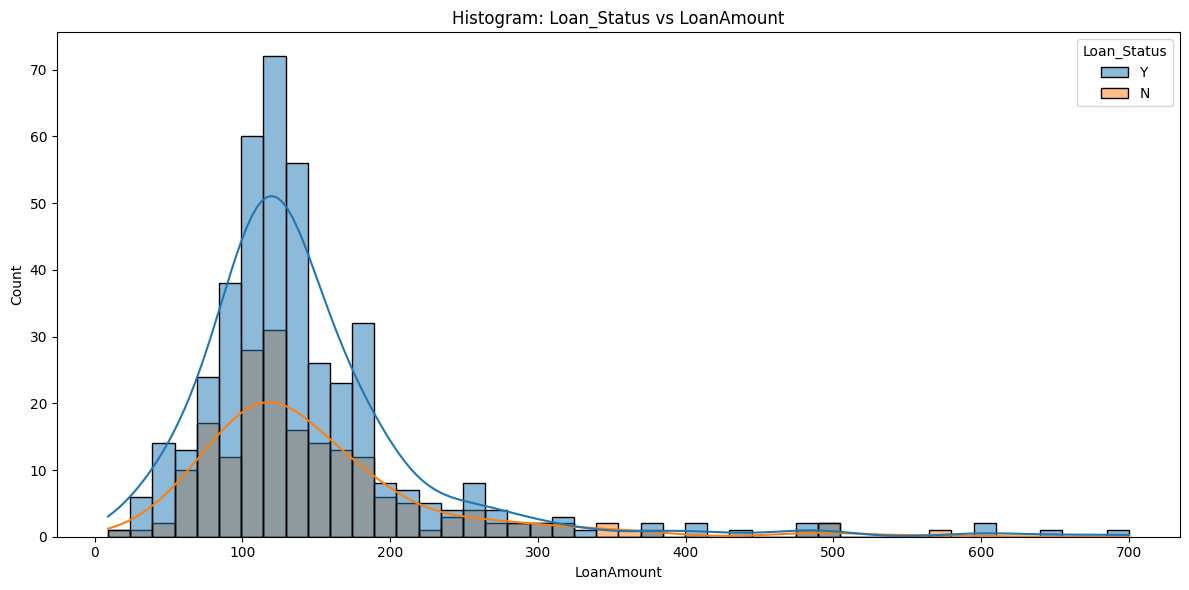

In [59]:
plt.figure(figsize=(12, 6))

sns.histplot(data=loan_data, x='LoanAmount', hue='Loan_Status', kde=True)
plt.title('Histogram: Loan_Status vs LoanAmount')
plt.tight_layout()
plt.show()

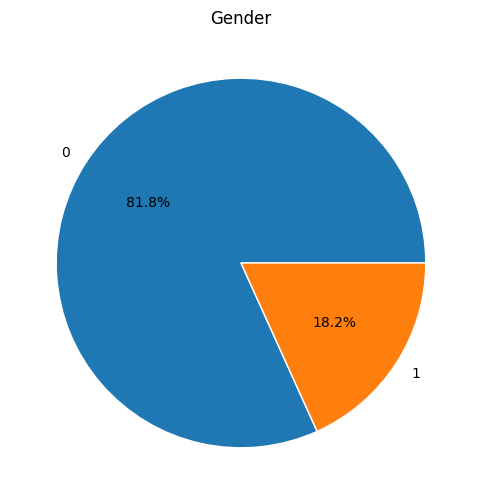

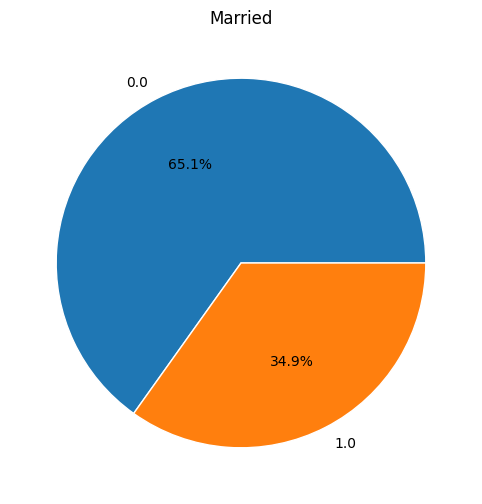

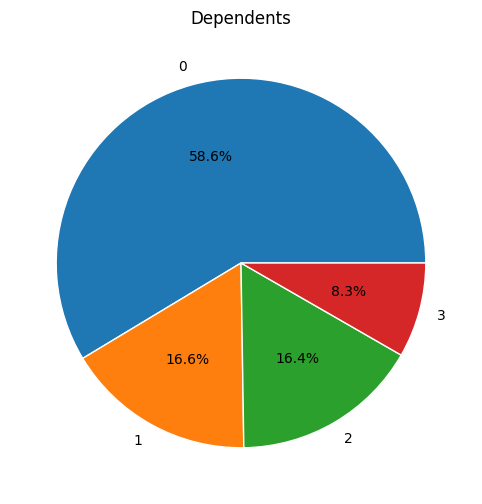

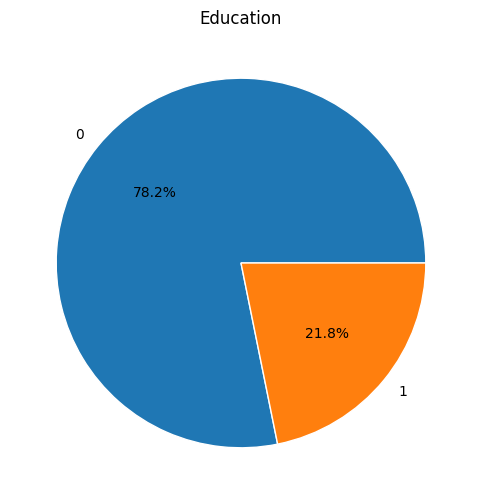

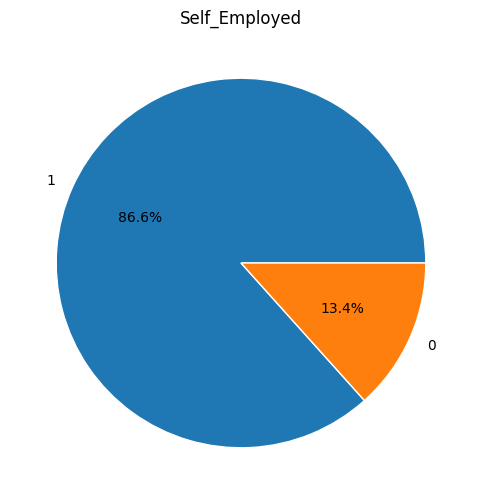

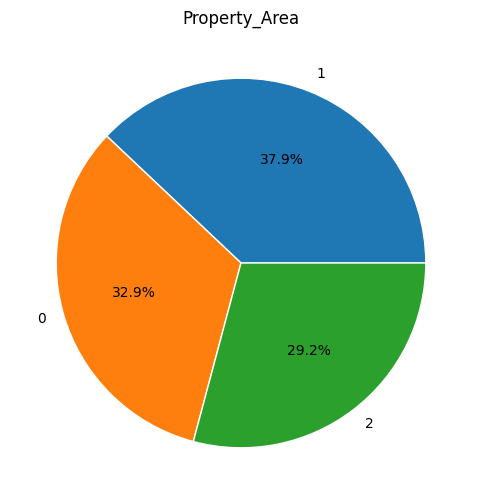

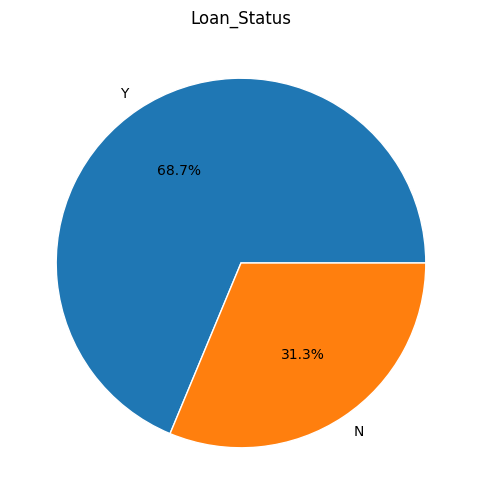

In [60]:
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
Cat = loan_data[categorical_cols]

for i in Cat.columns :
  x = Cat[i].value_counts()
  plt.figure(figsize=(8,6))
  plt.pie( x , labels=x.index , autopct='%1.1f%%' , wedgeprops= {'edgecolor': 'white'} )
  plt.title(i)
  plt.show()

In [61]:
y = loan_data['Loan_Status']

X = loan_data.drop(['Loan_ID', 'Loan_Status'], axis=1)

In [62]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(491, 11)
(123, 11)
(491,)
(123,)


In [67]:
from sklearn.linear_model import LogisticRegression

# Impute missing values in 'Married' column for X_train and X_test
X_train['Married'].fillna(X_train['Married'].mode()[0], inplace=True)
X_test['Married'].fillna(X_test['Married'].mode()[0], inplace=True)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("accuracy:",model.score(X_test, y_test))

accuracy: 0.7886178861788617


/tmp/ipykernel_1114/1453059588.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['Married'].fillna(X_train['Married'].mode()[0], inplace=True)
/tmp/ipykernel_1114/1453059588.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [65]:
test_data = pd.read_csv('test_Y3wMUE5_7gLdaTN.csv')
test_data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


In [68]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("accuracy:",model.score(X_test, y_test))

accuracy: 0.7886178861788617


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [69]:
print(len(test_data))
print(len(y_pred))
print(X_test.shape)
print(X.columns)

367
123
(123, 11)
Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')


In [72]:
# Create the submission DataFrame

# Make a copy to avoid modifying the original test_data loaded from CSV
test_df_processed = test_data.copy()

# Store original loan_data before any transformations to get correct modes
# This is needed because the 'loan_data' in the kernel state is already transformed.
original_loan_data_for_modes = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')

# --- Imputation of missing values in test_df_processed using modes from original_loan_data_for_modes ---
# Using .fillna() and assigning back to avoid FutureWarning with inplace=True
test_df_processed['Gender'] = test_df_processed['Gender'].fillna(original_loan_data_for_modes['Gender'].mode()[0])
test_df_processed['Married'] = test_df_processed['Married'].fillna(original_loan_data_for_modes['Married'].mode()[0])
test_df_processed['Dependents'] = test_df_processed['Dependents'].fillna(original_loan_data_for_modes['Dependents'].mode()[0])
test_df_processed['Self_Employed'] = test_df_processed['Self_Employed'].fillna(original_loan_data_for_modes['Self_Employed'].mode()[0])
test_df_processed['LoanAmount'] = test_df_processed['LoanAmount'].fillna(original_loan_data_for_modes['LoanAmount'].mode()[0])
test_df_processed['Loan_Amount_Term'] = test_df_processed['Loan_Amount_Term'].fillna(original_loan_data_for_modes['Loan_Amount_Term'].mode()[0])
test_df_processed['Credit_History'] = test_df_processed['Credit_History'].fillna(original_loan_data_for_modes['Credit_History'].mode()[0])

# --- Categorical to numerical mapping for test_df_processed ---
# Use the same mapping dictionaries as applied to loan_data (cell 9yFp24eGWj4R)
test_df_processed['Gender'] = test_df_processed['Gender'].map({'Male': 0, 'Female': 1})
test_df_processed['Married'] = test_df_processed['Married'].map({'Yes': 0, 'No': 1})
test_df_processed['Education'] = test_df_processed['Education'].map({'Graduate': 0, 'Not Graduate': 1})
test_df_processed['Self_Employed'] = test_df_processed['Self_Employed'].map({'Yes': 0, 'No': 1})
test_df_processed['Property_Area'] = test_df_processed['Property_Area'].map({'Urban': 0, 'Semiurban': 1, 'Rural': 2})

# Handle 'Dependents' column: replace '3+' with 3 and convert to numeric
test_df_processed['Dependents'] = test_df_processed['Dependents'].replace('3+', 3)
test_df_processed['Dependents'] = pd.to_numeric(test_df_processed['Dependents'])

# Now, drop 'Loan_ID' from test_df_processed, as it's not a feature for the model
test_df_processed = test_df_processed.drop('Loan_ID', axis=1)

# Ensure the columns in test_df_processed are in the same order as X_train
# This is crucial for consistent model input. X_train.columns is available from kernel state.
test_df_processed = test_df_processed[X_train.columns]

# Generate predictions for the preprocessed test_data
y_pred_on_test_data = model.predict(test_df_processed)

# Create the submission DataFrame using the original Loan_ID from test_data
# and the new predictions (y_pred_on_test_data)
submission = pd.DataFrame({'Loan_ID': test_data['Loan_ID'], 'Loan_Status': y_pred_on_test_data})
submission.to_csv('submission.csv', index=False)
submission.head(20)

,Loan_ID,Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,Y
5,LP001054,Y
6,LP001055,Y
7,LP001056,N
8,LP001059,Y
9,LP001067,Y
